# AI R&D Assignment — Parametric Curve Parameter Estimation

This notebook estimates the unknown parameters $\theta$, $M$, and $X$ from the given `xy_data.csv` points using numerical optimization.

The final recovered values are:

$$
\theta = 30^\circ, \quad M = 0.03, \quad X = 55
$$


## Given equation

The curve is defined as:

$$x(t)=t\cos(\theta)-e^{M|t|}\sin(0.3t)\sin(\theta)+X$$

$$y(t)=42+t\sin(\theta)+e^{M|t|}\sin(0.3t)\cos(\theta)$$

Parameter bounds:

- $0^\circ < \theta < 50^\circ$
- $-0.05 < M < 0.05$
- $0 < X < 100$
- $6 \leq t \leq 60$

The objective is to recover $\theta$, $M$, and $X$.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.spatial import cKDTree

DATA_PATH = "xy_data.csv"
os.makedirs("plots", exist_ok=True)

## 1. Load the data

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.head())
print("Shape:", df.shape)

data_points = df[["x", "y"]].to_numpy()

            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340
Shape: (1500, 2)


## 2. Visualize the given points

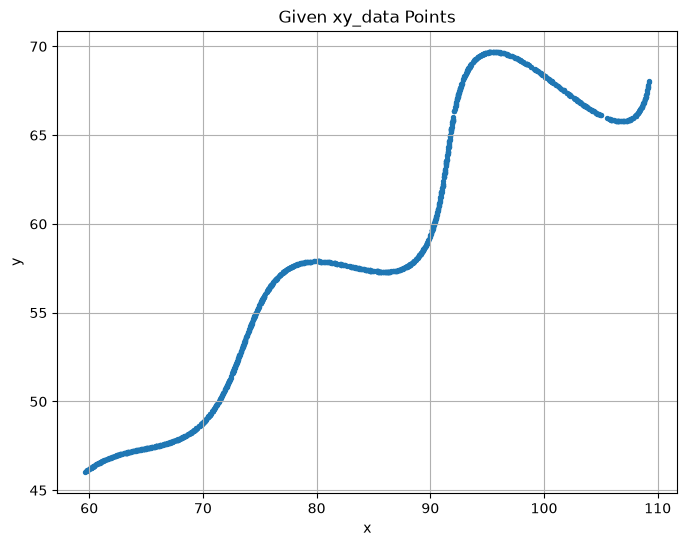

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(df["x"], df["y"], s=8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Given xy_data Points")
plt.grid(True)
plt.show()

## 3. Define the parametric curve

In [4]:
def generate_curve(theta_rad, M, X, n_points=1500):
    """Generate x,y points from the parametric curve for t in [6, 60]."""
    t = np.linspace(6, 60, n_points)
    exp_term = np.exp(M * np.abs(t))
    wave = np.sin(0.3 * t)

    x = t * np.cos(theta_rad) - exp_term * wave * np.sin(theta_rad) + X
    y = 42 + t * np.sin(theta_rad) + exp_term * wave * np.cos(theta_rad)

    return x, y

## 4. Define the loss function

The assignment mentions L1 distance. I used a symmetric nearest-neighbour L1 distance:

1. For each data point, find the closest point on the predicted curve.
2. For each predicted curve point, find the closest point in the data.
3. Add the average of both distances.

This is useful because the CSV points may not be ordered by the parameter $t$.

In [5]:
def symmetric_l1_loss(params, data_points):
    theta_deg, M, X = params
    theta_rad = np.deg2rad(theta_deg)

    x_pred, y_pred = generate_curve(theta_rad, M, X, n_points=len(data_points))
    curve_points = np.column_stack([x_pred, y_pred])

    # p=1 means Manhattan/L1 distance.
    tree_curve = cKDTree(curve_points)
    d_data_to_curve, _ = tree_curve.query(data_points, k=1, p=1)

    tree_data = cKDTree(data_points)
    d_curve_to_data, _ = tree_data.query(curve_points, k=1, p=1)

    return np.mean(d_data_to_curve) + np.mean(d_curve_to_data)

## 5. Run global optimization

I used `differential_evolution` because the equation is nonlinear, the parameters are bounded, and the method does not require gradients.

In [6]:
bounds = [
    (0, 50),        # theta in degrees
    (-0.05, 0.05),  # M
    (0, 100),       # X
]

result = differential_evolution(
    symmetric_l1_loss,
    bounds=bounds,
    args=(data_points,),
    seed=42,
    tol=1e-9,
    polish=True,
    updating="immediate",
    workers=1,
)

result

             message: Optimization terminated successfully.
             success: True
                 fun: 0.04008585827821475
                   x: [ 3.000e+01  3.000e-02  5.500e+01]
                 nit: 78
                nfev: 3631
          population: [[ 3.000e+01  3.000e-02  5.500e+01]
                       [ 3.000e+01  3.000e-02  5.500e+01]
                       ...
                       [ 3.000e+01  3.000e-02  5.500e+01]
                       [ 3.000e+01  3.000e-02  5.500e+01]]
 population_energies: [ 4.009e-02  4.009e-02 ...  4.009e-02  4.009e-02]

## 6. Recovered parameter values

In [7]:
theta_deg, M, X = result.x
theta_rad = np.deg2rad(theta_deg)

print(f"theta = {theta_deg:.6f} degrees")
print(f"theta = {theta_rad:.6f} radians")
print(f"M     = {M:.6f}")
print(f"X     = {X:.6f}")
print(f"Loss  = {result.fun:.10f}")

theta = 29.999563 degrees
theta = 0.523591 radians
M     = 0.030001
X     = 54.998552
Loss  = 0.0400858583


The recovered values are approximately:

$$
\theta = 30^\circ
$$

$$
M = 0.03
$$

$$
X = 55
$$

In radians:

$$
\theta = 0.523599
$$


## 7. Plot fitted curve against original data

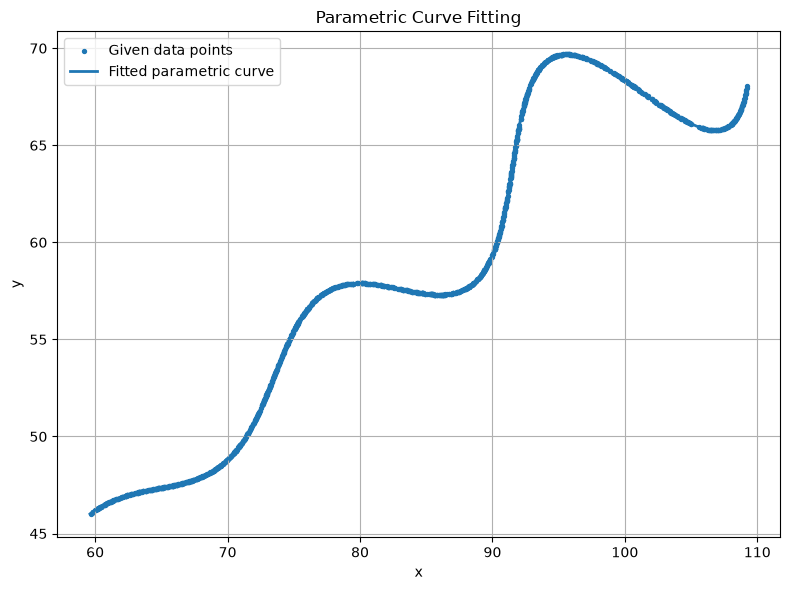

In [ ]:
x_fit, y_fit = generate_curve(theta_rad, M, X, n_points=1500)

plt.figure(figsize=(8, 6))
plt.scatter(df["x"], df["y"], s=8, label="Given data points")
plt.plot(x_fit, y_fit, linewidth=2, label="Fitted parametric curve")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parametric Curve Fitting")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/fitted_curve.png", dpi=300)
plt.show()

## 8. Final answer

Final parameter values:

$$
\theta = 30^\circ, \quad M = 0.03, \quad X = 55
$$

Final curve:

$$
x(t)=t\cos(0.523599)-e^{0.03|t|}\sin(0.3t)\sin(0.523599)+55
$$

$$
y(t)=42+t\sin(0.523599)+e^{0.03|t|}\sin(0.3t)\cos(0.523599)
$$

where:

$$
6 \leq t \leq 60
$$


## Desmos / README submission format

```latex
\left(t\cos(0.523599)-e^{0.03\left|t\right|}\sin(0.3t)\sin(0.523599)+55,42+t\sin(0.523599)+e^{0.03\left|t\right|}\sin(0.3t)\cos(0.523599)\right)
```
